In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, curve_fit
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

%matplotlib widget

# Hamiltonian and pulse definition

In [2]:
data_dir = './data/'
rabi_extracted = np.load(data_dir + 'rabi_osc/lambda_values.npz', allow_pickle=True)

lambdas = rabi_extracted['lambdas']

lambdas

array([0.526, 0.621, 0.753])

In [3]:
# Define basis states
# Motzoi's group: 4 levels are enough (https://arxiv.org/pdf/2512.19919)
ket0 = qt.basis(5, 0)
ket1 = qt.basis(5, 1)
ket2 = qt.basis(5, 2)
ket3 = qt.basis(5, 3)

bra0 = ket0.dag()
bra1 = ket1.dag()
bra2 = ket2.dag()
bra3 = ket3.dag()

# Hamiltonian builder
def Hamiltonian(lambdas, delta, Delta):
    lambda_0 = lambdas[0]
    lambda_1 = lambdas[1]
    lambda_2 = lambdas[2]
    H0 = delta*ket1*bra1 + (2*delta-Delta)*ket2*bra2 + (3*delta-3*Delta)*ket3*bra3
    H1_dag = (lambda_0/2)*(ket1*bra0)
    H1 = (lambda_0/2)*(ket0*bra1)
    H2_dag = (lambda_1/2)*(ket2*bra1)
    H2 = (lambda_1/2)*(ket1*bra2)
    H3_dag = (lambda_2/2)*(ket3*bra2)
    H3 = (lambda_2/2)*(ket2*bra3)
    return H0, H1, H1_dag, H2, H2_dag, H3, H3_dag

# Pulse-level waveform description

## Real part of the pulse
def Omega_x(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            return pulse_specs['A'] * (np.exp(-(t_local-pulse_specs['tg']/2)**2/(2*pulse_specs['sigma']**2)) - np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) \
                        / (1-np.exp(-pulse_specs['tg']**2/(8*pulse_specs['sigma']**2))) # normalization part, truncated Gaussian amplitude will be pulse_specs['A]
    return 0

## Imaginary part of the pulse / DRAG correction
def Omega_y(t, args):
    for item, pulse_specs in args.items():
        if item == 'clock':
            continue
        if t <= pulse_specs['start'] or t >= (pulse_specs['start'] + pulse_specs['tg']):
            continue
        else:
            t_local = t - pulse_specs['start']
            tg = pulse_specs['tg']
            sigma = pulse_specs['sigma']
            A = pulse_specs['A']

            # Gaussian normalization
            norm = 1 - np.exp(-tg**2 / (8 * sigma**2))
            gauss = np.exp(-(t_local - tg/2)**2 / (2 * sigma**2))
            offset = np.exp(-tg**2 / (8 * sigma**2))

            G = A * (gauss - offset) / norm
            dG = -A * (t_local - tg/2) / sigma**2 * gauss / norm

            # Raised-cosine window to ensure zeroes at the beginning and end of the pulse
            w = 0.5 * (1 - np.cos(2 * np.pi * t_local / tg))
            dw = (np.pi / tg) * np.sin(2 * np.pi * t_local / tg)
            result = dG * w + G * dw
            result_scaled = pulse_specs['beta']*result
            return result_scaled
    return 0

## Both components
def Omega(t, args):
    return Omega_x(t, args) - 1j*Omega_y(t, args)

## Pulse simulation helper, to create a pulse train
def add_pulse(pulse_train, pulse_name, start, tg, sigma, A, beta):
    pulse_train[pulse_name] = {'start': start, 'tg': tg, 'sigma': sigma, 'A': A, 'beta': beta}
    pulse_train['clock'] += tg

## Minimal example

### Pulse specs

In [4]:
amp_uncorrected = 0.2512 # rough Rabi calibrated, obtained from Rabi oscillation on 12
tg = 20 # 20 nanoseconds pulse
sigma = tg/4 # standard deviation of the truncated Gaussian
beta_demo = 0.1 # demo beta

In [5]:
# Initialize pulse

pulse_train = {'clock': 0}
add_pulse(pulse_train, pulse_name='Gaussian', start=pulse_train['clock'], tg=20, sigma=20/4, A=amp_uncorrected, beta=beta_demo)

times = np.linspace(0, 40, 100)
waveform_Gaussian = np.array([Omega_x(t, pulse_train) for t in times])
waveform_DRAG_1 = 1*np.gradient(waveform_Gaussian)
waveform_DRAG_2 = np.array([Omega_y(t, pulse_train) for t in times])
waveform_general = np.array([Omega(t, pulse_train) for t in times])

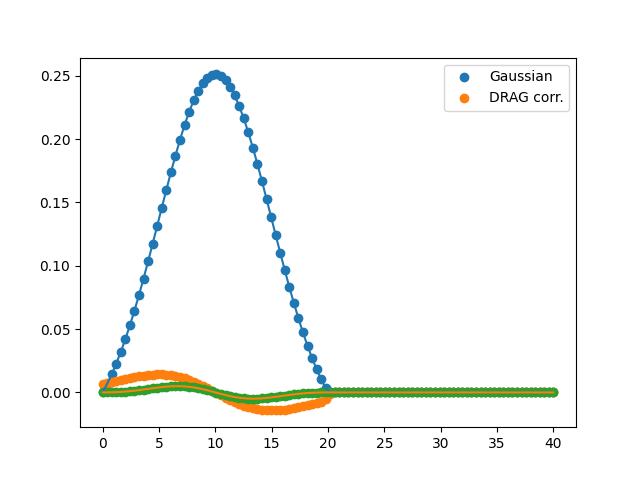

In [6]:
fig, ax = plt.subplots()
ax.scatter(times, waveform_Gaussian,label='Gaussian')
ax.plot(times, np.real(waveform_general))

ax.scatter(times, waveform_DRAG_1,label='DRAG corr.')
ax.plot(times, -np.imag(waveform_general))
ax.scatter(times, waveform_DRAG_2)
ax.legend()

# DRAPE experiment

### Multiple schemes of DRAPE at this point

Originally used range of DRAG correction

In [7]:
drape_sweep = np.load(data_dir + 'drag_and_ape/drag_ape_data.npz')

transmon_anharmonicity = 0.3071 # GHz
drape_sweep_beta = drape_sweep['beta_swept']
drape_sweep_beta_normalized = drape_sweep_beta/(-2*np.pi*transmon_anharmonicity)
drape_sweep_pops = drape_sweep['drape_pops']

drape_sweep, drape_sweep_beta_normalized*(-2*np.pi*transmon_anharmonicity)

(NpzFile './data/drag_and_ape/drag_ape_data.npz' with keys: beta_swept, drape_pops, y_fit_pops,
 array([-1.        , -0.98367347, -0.96734694, -0.95102041, -0.93469388,
        -0.91836735, -0.90204082, -0.88571429, -0.86938776, -0.85306122,
        -0.83673469, -0.82040816, -0.80408163, -0.7877551 , -0.77142857,
        -0.75510204, -0.73877551, -0.72244898, -0.70612245, -0.68979592,
        -0.67346939, -0.65714286, -0.64081633, -0.6244898 , -0.60816327,
        -0.59183673, -0.5755102 , -0.55918367, -0.54285714, -0.52653061,
        -0.51020408, -0.49387755, -0.47755102, -0.46122449, -0.44489796,
        -0.42857143, -0.4122449 , -0.39591837, -0.37959184, -0.36326531,
        -0.34693878, -0.33061224, -0.31428571, -0.29795918, -0.28163265,
        -0.26530612, -0.24897959, -0.23265306, -0.21632653, -0.2       ]))

Extended range: same beginning and end point but doubled the points

In [8]:
midpoints = (drape_sweep_beta[:-1] + drape_sweep_beta[1:]) / 2
extended_drape_sweep_beta = np.empty(drape_sweep_beta.size + midpoints.size)
extended_drape_sweep_beta[0::2] = drape_sweep_beta
extended_drape_sweep_beta[1::2] = midpoints
extended_drape_sweep_beta_normalized = extended_drape_sweep_beta/(-2*np.pi*transmon_anharmonicity)

extended_drape_sweep_beta_normalized*(-2*np.pi*transmon_anharmonicity)

array([-1.        , -0.99183673, -0.98367347, -0.9755102 , -0.96734694,
       -0.95918367, -0.95102041, -0.94285714, -0.93469388, -0.92653061,
       -0.91836735, -0.91020408, -0.90204082, -0.89387755, -0.88571429,
       -0.87755102, -0.86938776, -0.86122449, -0.85306122, -0.84489796,
       -0.83673469, -0.82857143, -0.82040816, -0.8122449 , -0.80408163,
       -0.79591837, -0.7877551 , -0.77959184, -0.77142857, -0.76326531,
       -0.75510204, -0.74693878, -0.73877551, -0.73061224, -0.72244898,
       -0.71428571, -0.70612245, -0.69795918, -0.68979592, -0.68163265,
       -0.67346939, -0.66530612, -0.65714286, -0.64897959, -0.64081633,
       -0.63265306, -0.6244898 , -0.61632653, -0.60816327, -0.6       ,
       -0.59183673, -0.58367347, -0.5755102 , -0.56734694, -0.55918367,
       -0.55102041, -0.54285714, -0.53469388, -0.52653061, -0.51836735,
       -0.51020408, -0.50204082, -0.49387755, -0.48571429, -0.47755102,
       -0.46938776, -0.46122449, -0.45306122, -0.44489796, -0.43

Zoomed in the believed-to-be the DRAG correction zone (-0.317355)

In [9]:
zoomed_drape_sweep_beta_normalized = np.linspace(-0.371355-0.001*0.371355, -0.371355+0.001*0.371355, 100)/(-2*np.pi*transmon_anharmonicity)

zoomed_drape_sweep_beta_normalized*(-2*np.pi*transmon_anharmonicity)

array([-0.37172636, -0.37171885, -0.37171135, -0.37170385, -0.37169635,
       -0.37168884, -0.37168134, -0.37167384, -0.37166634, -0.37165884,
       -0.37165133, -0.37164383, -0.37163633, -0.37162883, -0.37162133,
       -0.37161382, -0.37160632, -0.37159882, -0.37159132, -0.37158381,
       -0.37157631, -0.37156881, -0.37156131, -0.37155381, -0.3715463 ,
       -0.3715388 , -0.3715313 , -0.3715238 , -0.3715163 , -0.37150879,
       -0.37150129, -0.37149379, -0.37148629, -0.37147878, -0.37147128,
       -0.37146378, -0.37145628, -0.37144878, -0.37144127, -0.37143377,
       -0.37142627, -0.37141877, -0.37141127, -0.37140376, -0.37139626,
       -0.37138876, -0.37138126, -0.37137376, -0.37136625, -0.37135875,
       -0.37135125, -0.37134375, -0.37133624, -0.37132874, -0.37132124,
       -0.37131374, -0.37130624, -0.37129873, -0.37129123, -0.37128373,
       -0.37127623, -0.37126873, -0.37126122, -0.37125372, -0.37124622,
       -0.37123872, -0.37123122, -0.37122371, -0.37121621, -0.37

### DRAG simulation wrapper

In [10]:
# Simulation wrapper

def simulateDRAPE(gamma, rep_range, betas, A0, lambdas):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta

    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag= Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]

    pops = []
    for rep in rep_range:
        pops_versus_betas = []
        for beta in betas:
            phi=np.pi/2
            A0_phi = A0*np.exp(1j*phi) # DRAPE protocol, fixed at pi/2
            psi0 = -1j*ket1
            pulse_train = {'clock': 0}
            add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta) # Uplus
            counter = 0
            for r in range(rep): # (UminusUplus)(2*n+1)
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
                counter += 1
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=-A0, beta=beta)
                counter += 1
            add_pulse(pulse_train, 'map_phase_to_pop', start=pulse_train['clock'], tg=20, sigma=5, A=-A0_phi, beta=beta) # Uy minus
            print(pulse_train['clock'])
            times = np.linspace(0, pulse_train['clock'], 10000)
            options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
            result = qt.sesolve(H, psi0, times,
                                e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                                args=pulse_train, options=options)
            pops_versus_betas.append([result.expect[0][-1], result.expect[1][-1], result.expect[2][-1]])  # pop of |2⟩
            print(A0, lambdas, beta)
            print(np.array(pops_versus_betas).shape)
        pops.append(pops_versus_betas)
    return np.array(pops)

# Loss function
def lossDRAPE(gamma, pop_data, rep_range, betas, A0, lambdas):
    try:
        sim_data = simulateDRAPE(gamma, rep_range, betas, A0, lambdas)
        print(np.mean((sim_data - pop_data)**2))
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [12]:
# # === Optimization ===
# # This optimization takes around 1 hour to converge

# pop_data = drape_sweep_pops[:, :, 2]
# initial_guess = [-0.0007]
# bounds = [(-0.005, 0)]

# args = (pop_data, [1, 3, 5, 7, 9, 11], drape_sweep_beta_normalized, amp_90_12_scaled, lambdas)

# resultDRAPE_scaled = minimize(
#     lossDRAPE,
#     initial_guess,
#     args=args,
#     bounds=bounds,
#     method="L-BFGS-B"
# )

# print("Optimal gamma:", resultDRAPE_scaled.x[0])
# print("Final loss:", resultDRAPE_scaled.fun)

In [13]:
# resultDRAPE_gamma = -0.00035678567513997076 # THIS GAMMA ABSORBS ALL THE FLUCTUATION
# resultDRAPE_loss = 6.533422710405027e-05
# drape_simulation_zoomed = simulateDRAPE(resultDRAPE_gamma, [1, 3, 5, 7, 9, 11], zoomed_drape_sweep_beta_normalized, amp_uncorrected, lambdas)

In [14]:
data_drape_gammas = np.load(data_dir + 'drag_and_ape/drape_results_fit_various_gamma.npz', allow_pickle=True)
standard_drape_uncorrected_amp = np.load(data_dir + 'simu/drape_simulation_uncorrected_amp.npz', allow_pickle=True)
extended_drape_uncorrected_amp = np.load(data_dir + 'simu/extended_drape_simulation_uncorrected_amp.npz', allow_pickle=True)
zoomed_drape_uncorrected_amp = np.load(data_dir + 'simu/zoomed_drape_simulation_uncorrected_amp.npz', allow_pickle=True)

In [15]:
zoomed_drape_uncorrected_amp

NpzFile './data/simu/zoomed_drape_simulation_uncorrected_amp.npz' with keys: data

### Choose DRAPE scheme

In [16]:
drape_pops = zoomed_drape_uncorrected_amp['data']
drape_beta_range = zoomed_drape_sweep_beta_normalized

drape_pops.shape, drape_beta_range

((6, 100, 3),
 array([0.19264763, 0.19264374, 0.19263985, 0.19263597, 0.19263208,
        0.19262819, 0.1926243 , 0.19262041, 0.19261653, 0.19261264,
        0.19260875, 0.19260486, 0.19260097, 0.19259709, 0.1925932 ,
        0.19258931, 0.19258542, 0.19258153, 0.19257765, 0.19257376,
        0.19256987, 0.19256598, 0.19256209, 0.19255821, 0.19255432,
        0.19255043, 0.19254654, 0.19254265, 0.19253877, 0.19253488,
        0.19253099, 0.1925271 , 0.19252321, 0.19251933, 0.19251544,
        0.19251155, 0.19250766, 0.19250377, 0.19249989, 0.192496  ,
        0.19249211, 0.19248822, 0.19248433, 0.19248045, 0.19247656,
        0.19247267, 0.19246878, 0.19246489, 0.19246101, 0.19245712,
        0.19245323, 0.19244934, 0.19244545, 0.19244157, 0.19243768,
        0.19243379, 0.1924299 , 0.19242601, 0.19242213, 0.19241824,
        0.19241435, 0.19241046, 0.19240657, 0.19240269, 0.1923988 ,
        0.19239491, 0.19239102, 0.19238713, 0.19238325, 0.19237936,
        0.19237547, 0.19237158, 0.

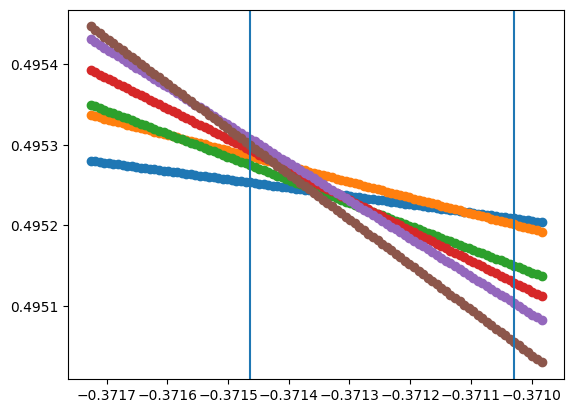

In [17]:
fig, ax = plt.subplots()

for i in range(6):
    ax.scatter(drape_beta_range*(-2*np.pi*transmon_anharmonicity), drape_pops[i][:, 2])

ax.axvline(drape_beta_range[35]*(-2*np.pi*transmon_anharmonicity))
ax.axvline(drape_beta_range[-7]*(-2*np.pi*transmon_anharmonicity))

# Investigate DRAPE using error parametrization

## Describing DRAPE using unitaries (correct ✔)

In [18]:
# Definitions of generalized Pauli matrices

def Lx12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, 1],
        [0, 1, 0]
    ]))

def Ly12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 0, -1j],
        [0, 1j, 0]
    ]))

def Lz12():
    return qt.Qobj(np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, -1]
    ]))

# Definitions of elementary operations

def overrotated_Xp2(epsilon, sign):
    if sign == 'plus':
        return (-1j*(np.pi/2+epsilon)/2*Lx12()).expm()
    elif sign == 'minus':
        return (1j*(np.pi/2+epsilon)/2*Lx12()).expm()
    else:
        print('Undefined sign')
        return 0

def overrotated_Yp2(epsilon, sign):
    if sign == 'plus':
        return (-1j*(np.pi/2+epsilon)/2*Ly12()).expm()
    elif sign == 'minus':
        return (1j*(np.pi/2+epsilon)/2*Ly12()).expm()
    else:
        print('Undefined sign')
        return 0

def Z(delta):
    return (1j*delta/2*Lz12()).expm()

def X_p2(epsilon, delta, sign):
    return Z(delta)*overrotated_Xp2(epsilon, sign)*Z(delta)

def Y_p2(epsilon, delta, sign):
    return Z(delta)*overrotated_Yp2(epsilon, sign)*Z(delta)

def DRAPE_unitary_probs(a0, p0, rep):
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    psi0 = -1j*ket1
    psi0 = X_p2(a0, p0, 'plus')*psi0
    for r in range(rep):
        psi0 = X_p2(a0, p0, 'minus')*X_p2(a0, p0, 'plus')*psi0
    psi0 = Y_p2(a0, p0, 'plus')*psi0
    pop1 = (np.abs(ket1.dag()*psi0))**2
    pop2 = (np.abs(ket2.dag()*psi0))**2
    return pop1, pop2

def DRAPE_unitary_simulation(a0, prop_cte, twist_point, idx_range):
    """
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    pops = []
    start, stop = idx_range
    rep_range = [1, 3, 5, 7, 9, 11]
    for rep in rep_range:
        pops_versus_p0 = []
        for p0 in extended_drape_sweep_beta[start:stop]:
            p0=prop_cte*(p0-twist_point)
            pop1, pop2 = DRAPE_unitary_probs(a0, p0, rep)
            pops_versus_p0.append([0, pop1, pop2])
        pops.append(pops_versus_p0)
    return np.array(pops)

def DRAPE_unitary_loss(params, idx_range):
    a0, cte = params
    try:
        sim_data = DRAPE_unitary_simulation(a0, cte, idx_range)  # shape (N, T)
        return np.mean((sim_data - pop_data) ** 2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6

## Describing DRAPE using the explicit form of these unitaries (correct ✔)

In [19]:
def Xpp2_explicit(eps, delta):
    A = np.cos(eps/2) - np.sin(eps/2)
    B = np.cos(eps/2) + np.sin(eps/2)
    return (1/np.sqrt(2)) * qt.Qobj([
        [np.sqrt(2), 0, 0],
        [0, A, -1j*B*np.exp(1j*delta)],
        [0, -1j*B*np.exp(1j*delta), A*np.exp(1j*2*delta)]
    ])

def Xmp2_explicit(eps, delta):
    A = np.cos(eps/2) - np.sin(eps/2)
    B = np.cos(eps/2) + np.sin(eps/2)
    return (1/np.sqrt(2)) * qt.Qobj([
        [np.sqrt(2), 0, 0],
        [0, A, 1j*B*np.exp(1j*delta)],
        [0, 1j*B*np.exp(1j*delta), A*np.exp(1j*2*delta)]
    ])

def XX2np1_explicit(eps, delta, n):
    k = 2*n + 1

    cos_theta = 0.5 * ((1 + np.sin(eps)) + (1 - np.sin(eps)) * np.cos(2*delta))
    theta = np.arccos(cos_theta)

    S_k   = np.sin(k*theta) / np.sin(theta)
    S_km1 = np.sin((k-1)*theta) / np.sin(theta)

    pref = np.exp(1j * k * 2 * delta)

    m11 = (S_k/2)*((1 - np.sin(eps))*np.exp(-1j*2*delta) + (1 + np.sin(eps))) - S_km1
    m22 = (S_k/2)*((1 + np.sin(eps)) + (1 - np.sin(eps))*np.exp(1j*2*delta)) - S_km1
    off = S_k * np.cos(eps) * np.sin(delta)

    return pref * qt.Qobj([
        [1/pref, 0, 0],
        [0, m11, -off],
        [0, off,  m22]
    ])

def Ymp2_explicit(eps, delta):
    A = np.cos(eps/2) - np.sin(eps/2)
    B = np.cos(eps/2) + np.sin(eps/2)
    return (1/np.sqrt(2)) * qt.Qobj([
        [np.sqrt(2), 0, 0],
        [0, A, B*np.exp(1j*delta)],
        [0, -B*np.exp(1j*delta), A*np.exp(1j*2*delta)]
    ])

def DRAPE_matrix_probs(a0, p0, rep):
    ket1 = qt.basis(3, 1)
    ket2 = qt.basis(3, 2)

    psi0 = -1j*ket1
    psi0 = Xpp2_explicit(a0, p0)*psi0
    n = (rep-1)/2
    psi0 = XX2np1_explicit(a0, p0, n)*psi0
    psi0 = Ymp2_explicit(a0, p0)*psi0

    pop1 = (np.abs(ket1.dag()*psi0))**2
    pop2 = (np.abs(ket2.dag()*psi0))**2
    return pop1, pop2

def DRAPE_matrix_simulation(a0, prop_cte, twist_point, idx_range):
    """
        Gate-based sim. Use only `a` (rotation) and `p` (phase) error.
    """

    pops = []
    start, stop = idx_range
    rep_range = [1, 3, 5, 7, 9, 11]
    for rep in rep_range:
        pops_versus_p0 = []
        for p0 in extended_drape_sweep_beta[start:stop]:
            p0=prop_cte*(p0-twist_point)
            pop1, pop2 = DRAPE_matrix_probs(a0, p0, rep)
            pops_versus_p0.append([0, pop1, pop2])
        pops.append(pops_versus_p0)
    return np.array(pops)

def DRAPE_matrix_loss(params, idx_range):
    a0, cte = params
    try:
        sim_data = DRAPE_matrix_simulation(a0, cte, idx_range)  # shape (N, T)
        return np.mean((sim_data - pop_data) ** 2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6

## Describing DRAPE using the closed-form of the final state (correct ✔)

In [20]:
def probs_psi_final_n(eps, delta, n):
    """
    Probabilities |<0|psi_final>|^2 and |<1|psi_final>|^2
      A^2 = 1 - sin(eps)
      B^2 = 1 + sin(eps)
    and keeping m11, m22 independent.
    """
    k = 2*n + 1
    delta = - delta

    # rotation quantities
    cos_theta = 0.5 * ((1 + np.sin(eps)) + (1 - np.sin(eps)) * np.cos(2*delta))
    theta = np.arccos(cos_theta)

    S_k   = np.sin(k*theta) / np.sin(theta)
    S_km1 = np.sin((k-1)*theta) / np.sin(theta)

    # matrix elements
    m11 = (S_k/2)*((1 - np.sin(eps))*np.exp(-1j*2*delta)
                   + (1 + np.sin(eps))) - S_km1

    m22 = (S_k/2)*((1 + np.sin(eps))
                   + (1 - np.sin(eps))*np.exp(1j*2*delta)) - S_km1

    off = S_k * np.cos(eps) * np.sin(delta)  # real

    # amplitudes
    psi0 = 0.5 * (
        -1j*(1 - np.sin(eps))*m11
        + (1+1j)*np.cos(eps)*np.exp(1j*delta)*off
        + (1 + np.sin(eps))*np.exp(1j*2*delta)*m22
    )

    psi1 = 0.5 * (
        -1j*np.cos(eps)*np.exp(1j*delta)*m11
        - np.cos(eps)*np.exp(1j*3*delta)*m22
        + np.exp(1j*2*delta)*off*((1 + np.sin(eps)) - 1j*(1 - np.sin(eps)))
    )

    P1 = abs(psi0)**2
    P2 = abs(psi1)**2

    return P1, P2

def DRAPE_analytic_simulation(eps, prop_cte, twist_point, idx_range):
    pops = []
    start, stop = idx_range
    rep_range = [0, 1, 2, 3, 4, 5]
    for rep in rep_range:
        pops_versus_p0 = []
        for p0 in extended_drape_sweep_beta[start:stop]:
            p0=prop_cte*(p0-twist_point)
            pop1, pop2 = probs_psi_final_n(eps, p0, rep)
            pops_versus_p0.append([0, pop1, pop2])
        pops.append(pops_versus_p0)
    return np.array(pops)

Closed-form of the final state:
\begin{align}
|\Psi_\text{DRAPE}\rangle =
    \frac{1}{2}\begin{pmatrix}
        -i(1-\sin\epsilon)M_{11}+S_k(\theta)(1+i)\cos^2\epsilon\sin\delta e^{i\delta}+(1+\sin\epsilon)e^{i2\delta}M_{22} \\
        -e^{i\delta}\cos\epsilon[iM_{11}+e^{i2\delta}M_{22}]+S_k(\theta)\cos\epsilon\sin\delta e^{i2\delta}(1+i)(\sin\epsilon-i)
    \end{pmatrix}
\end{align}
where $S_k(\theta)=\frac{\sin(k\theta)}{\sin\theta}$ is related to the Chebyshev polynomials of the second kind and $\theta=\cos^{-1}[\frac{1}{2}((1+\sin\epsilon)+(1-\sin\epsilon)\cos2\delta)]$, and
\begin{align}
    M_{11}=\frac{S_k(\theta)}{2}[(1-\sin\epsilon)e^{-i2\delta}+(1+\sin\epsilon)] - S_{k-1}(\theta),\\
    M_{22}=M_{11}^*.
\end{align}

### Expanded

In [21]:
def probs_psi_drape(epsilon, delta, k):
    delta = -delta
    p1 = (1+np.sin(epsilon)**2)/2 - delta*np.cos(epsilon)**2*(k+1-2*k*np.sin(epsilon))
    p2 = np.cos(epsilon)**2/2 + delta*np.cos(epsilon)**2*(k+1-2*k*np.sin(epsilon))
    return p1, p2

# Extracting $\epsilon, \beta_0, \chi$

### The easy case first: Linear $\delta \ll 1$

In [22]:
linear_beta_start_idx, linear_beta_end_idx = None, None

In [23]:
ks = np.array([1, 3, 5, 7, 9, 11])
# what is the beta range we *should* use
betas = drape_beta_range[linear_beta_start_idx:linear_beta_end_idx]*(-2*np.pi*transmon_anharmonicity)
k_mesh, beta_mesh = np.meshgrid(ks, betas)

def model_func(vars, eps0, beta0, xi0):
    beta, k = vars
    term1 = np.cos(eps0)**2 / 2
    term2 = -xi0 * (beta - beta0) * np.cos(eps0)**2 * (k + 1 - 2*k*np.sin(eps0))
    return term1 + term2

# np.cos(epsilon)**2/2 + delta*np.cos(epsilon)**2*(k+1-2*k*np.sin(epsilon))

f_data = drape_pops[:, linear_beta_start_idx:linear_beta_end_idx, 2].T

# --- STEP 1: LINEAR REGRESSION PER K TO FIND Mk AND Ck ---
mk_list = []
ck_list = []

print("--- Step 1: Individual fits per k ---")
for i, k in enumerate(ks):
    # Slice data for this specific k
    f_k = f_data[:, i]

    # Fit f = Mk * beta + Ck
    popt, _ = curve_fit(lambda b, m, c: m*b + c, betas, f_k)
    mk_list.append(popt[0])
    ck_list.append(popt[1])

mk_list = np.array(mk_list)
ck_list = np.array(ck_list)

# --- STEP 2: FIT Mk vs k TO FIND eps0 AND xi ---
# Mk = (xi * cos^2(eps0) * (1 - 2sin(eps0))) * k + (xi * cos^2(eps0))
# Let Mk = A*k + B
popt_m, _ = curve_fit(lambda k_val, a, b: a*k_val + b, ks, mk_list)
A, B = popt_m

# Solve for eps0: A/B = 1 - 2*sin(eps0)
sin_eps0_guess = (1 - A/B) / 2
eps0_guess = np.arcsin(sin_eps0_guess)

# Solve for xi: B = xi * cos^2(eps0)
xi_guess = B / (np.cos(eps0_guess)**2)

# --- STEP 3: FIT Ck vs Mk TO FIND beta0 ---
# Ck = -beta0 * Mk + (cos^2(eps0)/2)
popt_c, _ = curve_fit(lambda m_val, slope, intercept: slope*m_val + intercept, mk_list, ck_list)
beta0_guess = popt_c[0]

initial_guesses = [eps0_guess, beta0_guess, xi_guess]
print(f"Initial Guesses: eps0={eps0_guess:.3f}, beta0={beta0_guess:.3f}, xi={xi_guess:.3f}\n")

# --- STEP 4: GLOBAL NON-LINEAR LEAST SQUARES ---
# Flatten the grids for curve_fit
x_data = np.vstack((beta_mesh.ravel(), k_mesh.ravel()))
y_data = f_data.ravel()

popt_final, pcov = curve_fit(model_func, x_data, y_data, p0=initial_guesses)

eps0_final, beta0_final, xi_final = popt_final

print("--- FINAL ESTIMATED PARAMETERS ---")
print(f"epsilon_0: {eps0_final:.4f} (Eye: {0.0977})")
print(f"beta_0:    {beta0_final:.4f} (Eye: {-0.371355})")
print(f"xi:        {xi_final:.4f} (Eye: {0.06})")

--- Step 1: Individual fits per k ---
Initial Guesses: eps0=0.098, beta0=0.371, xi=-0.058

--- FINAL ESTIMATED PARAMETERS ---
epsilon_0: 0.0976 (Eye: 0.0977)
beta_0:    -0.3714 (Eye: -0.371355)
xi:        0.0576 (Eye: 0.06)


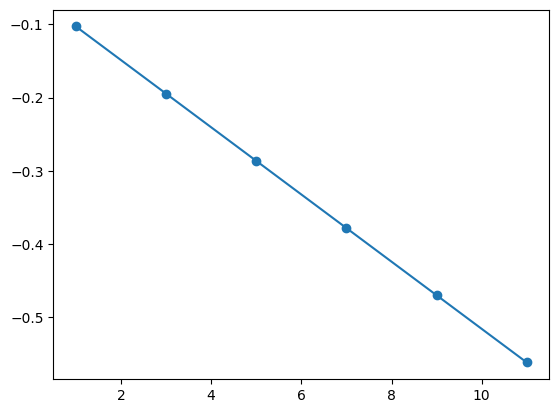

In [24]:
fig, ax = plt.subplots()
ax.scatter(ks, mk_list)
ax.plot(ks, A*ks+B)

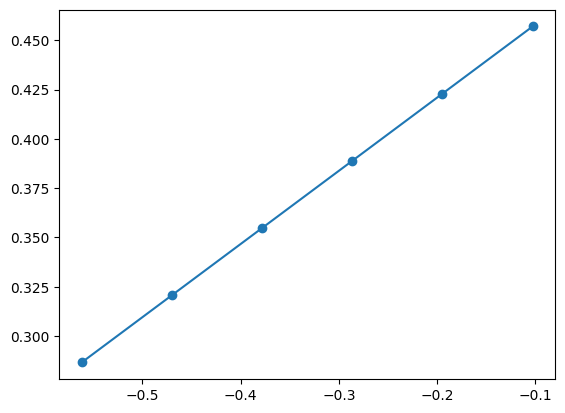

In [25]:
fig, ax = plt.subplots()
ax.scatter(mk_list, ck_list)
ax.plot(mk_list, mk_list*beta0_guess+0.5*np.cos(eps0_guess)**2)

In [26]:
prop_cte = xi_final
a0 = eps0_final
twist_point = beta0_final

betas_linear = drape_beta_range[linear_beta_start_idx:linear_beta_end_idx]*(-2*np.pi*transmon_anharmonicity)

p2_th_small_expand_deltas = []

for k in ks:
    p2_th_small_deltas_vs_p0 = []
    for p0 in betas_linear:
        p0=prop_cte*(p0-twist_point)
        pop1, pop2 = probs_psi_drape(a0, p0, k)
        p2_th_small_deltas_vs_p0.append([0, pop1, pop2])
    p2_th_small_expand_deltas.append(p2_th_small_deltas_vs_p0)

p2_th_small_expand_deltas = np.array(p2_th_small_expand_deltas)
p2_th_small_expand_deltas.shape

(6, 100, 3)

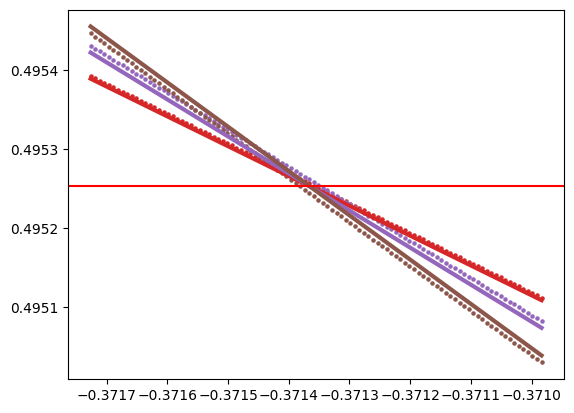

In [27]:
fig, ax = plt.subplots()

for i in range(3, 6, 1):
    ax.scatter(drape_beta_range*(-2*np.pi*transmon_anharmonicity), drape_pops[i][:, 2], color=colors[i], s=5)
    ax.plot(betas_linear, p2_th_small_expand_deltas[i][:, 2], color=colors[i], linewidth=3)

ax.axhline(np.cos(eps0_final)**2/2, color='red')

### Non-linear ($\delta$ arbitrary)

In [28]:
from scipy.optimize import curve_fit, differential_evolution

In [29]:
def probs_psi_final_n(beta, k, eps0, beta0, xi):
    """
    Probabilities |<0|psi_final>|^2 and |<1|psi_final>|^2
      A^2 = 1 - sin(eps)
      B^2 = 1 + sin(eps)
    and keeping m11, m22 independent.
    """

    delta = -xi*(beta-beta0)

    # rotation quantities
    cos_theta = 0.5 * ((1 + np.sin(eps0)) + (1 - np.sin(eps0)) * np.cos(2*delta))
    theta = np.arccos(cos_theta)

    S_k   = np.sin(k*theta) / np.sin(theta)
    S_km1 = np.sin((k-1)*theta) / np.sin(theta)

    # matrix elements
    m11 = (S_k/2)*((1 - np.sin(eps0))*np.exp(-1j*2*delta)
                   + (1 + np.sin(eps0))) - S_km1

    m22 = (S_k/2)*((1 + np.sin(eps0))
                   + (1 - np.sin(eps0))*np.exp(1j*2*delta)) - S_km1

    off = S_k * np.cos(eps0) * np.sin(delta)  # real

    # amplitudes
    psi0 = 0.5 * (
        -1j*(1 - np.sin(eps0))*m11
        + (1+1j)*np.cos(eps0)*np.exp(1j*delta)*off
        + (1 + np.sin(eps0))*np.exp(1j*2*delta)*m22
    )

    psi1 = 0.5 * (
        -1j*np.cos(eps0)*np.exp(1j*delta)*m11
        - np.cos(eps0)*np.exp(1j*3*delta)*m22
        + np.exp(1j*2*delta)*off*((1 + np.sin(eps0)) - 1j*(1 - np.sin(eps0)))
    )

    P1 = abs(psi0)**2
    P2 = abs(psi1)**2

    return P1, P2

# Vectorize for speed and array handling
v_model = np.vectorize(probs_psi_final_n)

def global_wrapper(vars, eps0, beta0, xi):
    beta, k = vars
    return v_model(beta, k, eps0, beta0, xi)[1]

In [30]:
ks = np.array([1, 3, 5, 7, 9, 11])

blackbox_beta_start_idx, blackbox_beta_end_idx = None, None

betas_blackbox = drape_beta_range[blackbox_beta_start_idx:blackbox_beta_end_idx]*(-2*np.pi*transmon_anharmonicity)
k_mesh, beta_mesh = np.meshgrid(ks, betas_blackbox)

f_obs = drape_pops[:, blackbox_beta_start_idx:blackbox_beta_end_idx, 2].T

beta_flat = beta_mesh.flatten()
k_flat = k_mesh.flatten()
f_flat = f_obs.flatten()

# --- 4. THE TWO-STAGE ESTIMATION ---

# Stage A: Global Scout
def objective(p, b, k, f):
    return np.sum((f - global_wrapper((b, k), *p))**2)

print("Searching for parameters...")
bounds = [(eps0_final-0.05*np.abs(eps0_final), eps0_final+0.05*np.abs(eps0_final)),
          (beta0_final-0.05*np.abs(beta0_final), beta0_final+0.05*np.abs(beta0_final)),
          (xi_final-0.05*np.abs(xi_final), xi_final+0.05*np.abs(xi_final))]

res = differential_evolution(objective, bounds, args=(beta_flat, k_flat, f_flat))
scout_guess = res.x

# Stage B: Final Refinement
popt, pcov = curve_fit(global_wrapper, (beta_flat, k_flat), f_flat, p0=scout_guess)
errors = np.sqrt(np.diag(pcov))

Searching for parameters...


C:\Users\tng-admin\AppData\Local\Temp\ipykernel_9112\1576370371.py:15: RuntimeWarning: invalid value encountered in scalar divide
  S_k   = np.sin(k*theta) / np.sin(theta)
C:\Users\tng-admin\AppData\Local\Temp\ipykernel_9112\1576370371.py:16: RuntimeWarning: invalid value encountered in scalar divide
  S_km1 = np.sin((k-1)*theta) / np.sin(theta)


In [31]:
print(f'Blackbox eps0: {popt[0]}, Linear eps0: {eps0_final}')
print(f'Blackbox beta0: {popt[1]}, Linear beta0: {beta0_final}')
print(f'Blackbox xi: {popt[2]}, Linear xi: {xi_final}')

Blackbox eps0: 0.09759109962814634, Linear eps0: 0.09759109343513044
Blackbox beta0: -0.3713655762574883, Linear beta0: -0.3713655800010495
Blackbox xi: 0.057551108750099715, Linear xi: 0.05755115634459266


In [32]:
p2_blackbox = []

for k in ks:
    p2_blackbox_vs_p0 = []
    for p0 in betas_blackbox:
        pop1, pop2 = probs_psi_final_n(p0, k, popt[0], popt[1], popt[2])
        p2_blackbox_vs_p0.append([0, pop1, pop2])
    p2_blackbox.append(p2_blackbox_vs_p0)

p2_blackbox = np.array(p2_blackbox)
p2_blackbox.shape

(6, 100, 3)

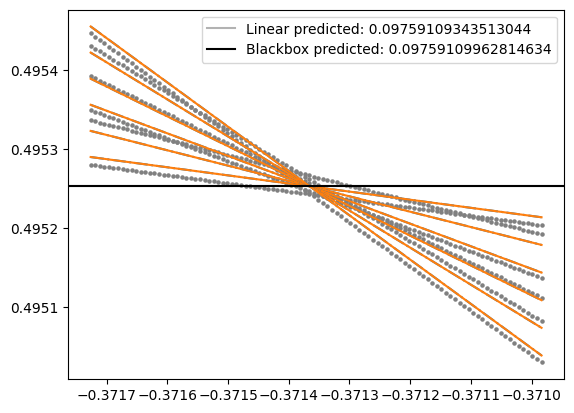

In [33]:
fig, ax = plt.subplots()

for i in range(6):
    ax.plot(betas_linear, p2_th_small_expand_deltas[i][:, 2], color='tab:blue', linestyle='-.')
    ax.plot(betas_blackbox, p2_blackbox[i][:, 2], color='tab:orange')
    ax.scatter(drape_beta_range*(-2*np.pi*transmon_anharmonicity), drape_pops[i][:,2], color='gray',s=5)

ax.axhline(0.5*np.cos(eps0_final)**2, color='black', alpha=0.3, label=f'Linear predicted: {eps0_final}')
ax.axhline(0.5*np.cos(popt[0])**2, color='black', alpha=1, label=f'Blackbox predicted: {popt[0]}')
ax.legend()

# Test with AAE

In [34]:
perfect_eps0 = 0.097675

amp_perfect = amp_uncorrected/(1+2*perfect_eps0/np.pi)

amp_perfect

0.23649434722313556

In [35]:
amp_scaled_linear = amp_uncorrected/(1+2*eps0_final/np.pi)
amp_scaled_blackbox = amp_uncorrected/(1+2*popt[0]/np.pi)

print(amp_scaled_linear, amp_scaled_blackbox)

0.2365062410003518 0.23650624012244603


In [36]:
# Simulation wrapper
def simulateAAE(gamma, N_values, A0, lambdas, beta):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta
    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag = Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]

    pops = []
    for N in N_values:
        psi0 = ket1
        pulse_train = {'clock': 0}
        add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
        counter = 0
        for i in range(N):
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter += 1
            add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
            counter += 1
        times = np.linspace(0, pulse_train['clock'], 10000)
        options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
        result = qt.sesolve(H, psi0, times,
                            e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                            args=pulse_train, options=options)
        pops.append(result.expect[2][-1])  # pop of |2⟩
    print(A0, lambdas, beta)
    return np.array(pops)

# Loss function
def lossAAE(gamma, pop_data, N_values, A0, lambdas, beta):
    try:
        sim_data = simulateAAE(gamma, N_values, A0, lambdas, beta)
        print(np.mean((sim_data - pop_data)**2))
        return np.mean((sim_data - pop_data)**2)
    except Exception as e:
        print("Simulation error:", e)
        return 1e6  # Penalty

In [37]:
aae_uncorrected = np.load(data_dir + '/amplifying_amplitude_error/aae_uncorrected.npz')
aae_Nvalues = aae_uncorrected['N']
resultDRAPE_gamma = -0.00035678567513997076 # THIS GAMMA ABSORBS ALL THE FLUCTUATION

aae_rerun_linear = simulateAAE(gamma=resultDRAPE_gamma, N_values=aae_Nvalues, A0=amp_scaled_linear, lambdas=lambdas, beta=beta0_final/(2*np.pi*0.3071))
aae_rerun_blackbox = simulateAAE(gamma=resultDRAPE_gamma, N_values=aae_Nvalues, A0=amp_scaled_blackbox, lambdas=lambdas, beta=popt[1]/(2*np.pi*0.3071))
aae_rerun_perfect = simulateAAE(gamma=resultDRAPE_gamma, N_values=aae_Nvalues, A0=amp_perfect, lambdas=lambdas, beta=popt[1]/(2*np.pi*0.3071))

c:\Users\tng-admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


0.2365062410003518 [0.526 0.621 0.753] -0.19246065695654754
0.23650624012244603 [0.526 0.621 0.753] -0.19246065501644244
0.23649434722313556 [0.526 0.621 0.753] -0.19246065501644244


(0.0, 1.0)

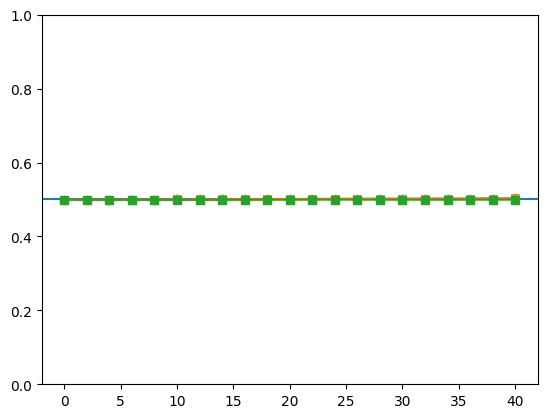

In [38]:
fig, ax = plt.subplots()

ax.axhline(0.5)
ax.plot(aae_Nvalues, aae_rerun_linear, '-x')
ax.plot(aae_Nvalues, aae_rerun_blackbox, '-o')
ax.plot(aae_Nvalues, aae_rerun_perfect, '-s')
ax.set_ylim(0, 1.0)

# Further exploration

## Geometrical interpretation of DRAPE

In [39]:
def overrotated_Xp2(epsilon, sign):
    if sign == 'plus':
        return (-1j*(np.pi/2+epsilon)/2*qt.sigmax()).expm()
    elif sign == 'minus':
        return (1j*(np.pi/2+epsilon)/2*qt.sigmax()).expm()
    else:
        print('Undefined sign')
        return 0

def overrotated_Yp2(epsilon, sign):
    if sign == 'plus':
        return (-1j*(np.pi/2+epsilon)/2*qt.sigmay()).expm()
    elif sign == 'minus':
        return (1j*(np.pi/2+epsilon)/2*qt.sigmay()).expm()
    else:
        print('Undefined sign')
        return 0

def Z(delta):
    return (1j*delta/2*qt.sigmaz()).expm()

def X_p2(epsilon, delta, sign):
    return Z(delta)*overrotated_Xp2(epsilon, sign)*Z(delta)

def Y_p2(epsilon, delta, sign):
    return Z(delta)*overrotated_Yp2(epsilon, sign)*Z(delta)

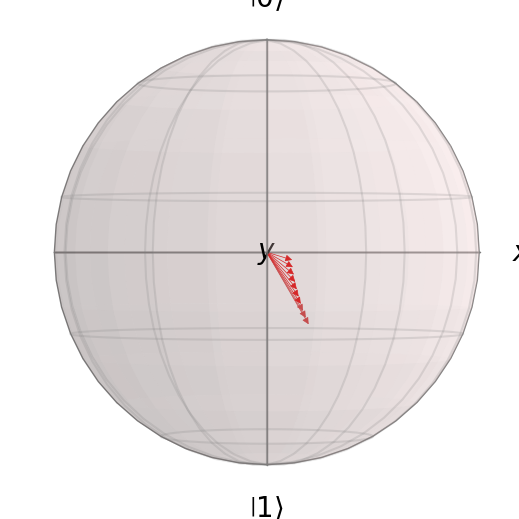

In [40]:
epsilon = 0.01
delta = 0.01

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

psi0 = -1j*ket0

b = qt.Bloch(figsize=(5, 5))
b.vector_mutation = 10
b.vector_width = 0.5

states = []
bloch_coords = []

k = 3

for N in [2*n+1 for n in range(10)]:
    psi = (X_p2(epsilon, delta, 'plus'))**(4*k+1) * psi0
    psi = (X_p2(epsilon, delta, 'minus')*X_p2(epsilon, delta, 'plus'))**N * psi
    psi = Y_p2(epsilon, delta, 'minus') * psi
    x = qt.expect(qt.sigmax(), psi)
    y = qt.expect(qt.sigmay(), psi)
    z = qt.expect(qt.sigmaz(), psi)
    states.append(psi)
    bloch_coords.append([x, y, z])

b.vector_color = ['tab:red' for _ in range(len(states))]
# Add Bloch vectors
b.add_states(states)
b.view = [180, 0]
# Display the Bloch sphere
b.make_sphere()
b.show()
b.save(f'fig1.png')

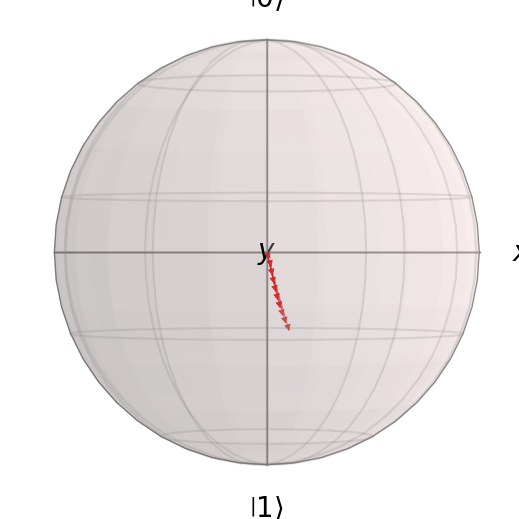

In [41]:
epsilon = 0.03
delta = 0.01

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

psi0 = -1j*ket0

b = qt.Bloch(figsize=(5, 5))
b.vector_mutation = 10
b.vector_width = 0.5

states = []
bloch_coords = []

k = 3

for N in [2*n+1 for n in range(10)]:
    psi = X_p2(epsilon, delta, 'plus') * psi0
    psi = (X_p2(epsilon, delta, 'minus')*X_p2(epsilon, delta, 'plus'))**N * psi
    psi = Y_p2(epsilon, delta, 'minus') * psi
    x = qt.expect(qt.sigmax(), psi)
    y = qt.expect(qt.sigmay(), psi)
    z = qt.expect(qt.sigmaz(), psi)
    states.append(psi)
    bloch_coords.append([x, y, z])

b.vector_color = ['tab:red' for _ in range(len(states))]
# Add Bloch vectors
b.add_states(states)
b.view = [180, 0]
# Display the Bloch sphere
b.make_sphere()
b.show()
b.save(f'fig2.png')

In [42]:
(X_p2(epsilon, delta, 'plus'))**4

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-9.98188883e-01-0.00058376j -4.06455161e-20+0.06015491j]
 [-5.37995787e-19+0.06015491j -9.98188883e-01+0.00058376j]]

In [43]:
# Conclusion 22/3: To know the optimal position of the pseudo operator that amplifies rotation errors, look not at the Bloch sphere, but the DRAPE protocol.

# Behavior of DRAPE protocol when adding rotation amplification

In [67]:
def simulateDRAPE_extended(gamma, ell, rep_range, betas, A0, lambdas):
    Delta = -2*np.pi*0.3071
    delta = Delta - gamma * Delta

    H0, H1, H1_dag, H2, H2_dag, H3, H3_dag= Hamiltonian(lambdas, delta, Delta)
    H = [H0, [H1, lambda t, args: np.conjugate(Omega(t, args))], [H1_dag, lambda t, args: (Omega(t, args))],
            [H2, lambda t, args: np.conjugate(Omega(t, args))], [H2_dag, lambda t, args: (Omega(t, args))],
            [H3, lambda t, args: np.conjugate(Omega(t, args))], [H3_dag, lambda t, args: (Omega(t, args))]]

    pops = []
    for rep in rep_range:
        pops_versus_betas = []
        for beta in betas:
            phi=np.pi/2
            A0_phi = A0*np.exp(1j*phi) # DRAPE protocol, fixed at pi/2
            psi0 = -1j*ket1
            pulse_train = {'clock': 0}
            add_pulse(pulse_train, 'pulse_init', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta) # Uplus
            counter = 0
            for r in range(rep): # (UminusUplus)(2*n+1)
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta)
                counter += 1
                add_pulse(pulse_train, f'pulse_{counter}', start=pulse_train['clock'], tg=20, sigma=5, A=-A0, beta=beta)
                counter += 1
            for l in range(4*ell):
                    add_pulse(pulse_train, f'pulse_{l}', start=pulse_train['clock'], tg=20, sigma=5, A=A0, beta=beta) # Uplus
                    counter += 1
            add_pulse(pulse_train, 'map_phase_to_pop', start=pulse_train['clock'], tg=20, sigma=5, A=-A0_phi, beta=beta) # Uy minus
            print(pulse_train['clock'])
            times = np.linspace(0, pulse_train['clock'], 10000)
            options = qt.Options(store_states=False, atol=1e-10, rtol=1e-10)
            result = qt.sesolve(H, psi0, times,
                                e_ops=[ket0*bra0, ket1*bra1, ket2*bra2, ket3*bra3],
                                args=pulse_train, options=options)
            pops_versus_betas.append([result.expect[0][-1], result.expect[1][-1], result.expect[2][-1]])  # pop of |2⟩
            print(A0, lambdas, beta)
            print(np.array(pops_versus_betas).shape)
        pops.append(pops_versus_betas)
    return np.array(pops)

In [47]:
resultDRAPE_gamma = -0.00035678567513997076 # THIS GAMMA ABSORBS ALL THE FLUCTUATION
resultDRAPE_loss = 6.533422710405027e-05
drape_simulation = simulateDRAPE_extended(resultDRAPE_gamma, 0, [1, 3, 5, 7, 9, 11], drape_sweep_beta_normalized, amp_uncorrected, lambdas)

80
0.2512 [0.526 0.621 0.753] 0.5182511986059765
(1, 3)
80
0.2512 [0.526 0.621 0.753] 0.5097899545471033
(2, 3)
80
0.2512 [0.526 0.621 0.753] 0.5013287104882302
(3, 3)
80
0.2512 [0.526 0.621 0.753] 0.49286746642935714
(4, 3)
80
0.2512 [0.526 0.621 0.753] 0.4844062223704841
(5, 3)
80
0.2512 [0.526 0.621 0.753] 0.475944978311611
(6, 3)
80
0.2512 [0.526 0.621 0.753] 0.46748373425273787
(7, 3)
80
0.2512 [0.526 0.621 0.753] 0.4590224901938648
(8, 3)
80
0.2512 [0.526 0.621 0.753] 0.4505612461349917
(9, 3)
80
0.2512 [0.526 0.621 0.753] 0.44210000207611866
(10, 3)
80
0.2512 [0.526 0.621 0.753] 0.4336387580172456
(11, 3)
80
0.2512 [0.526 0.621 0.753] 0.42517751395837244
(12, 3)
80
0.2512 [0.526 0.621 0.753] 0.4167162698994994
(13, 3)
80
0.2512 [0.526 0.621 0.753] 0.40825502584062634
(14, 3)
80
0.2512 [0.526 0.621 0.753] 0.3997937817817532
(15, 3)
80
0.2512 [0.526 0.621 0.753] 0.3913325377228801
(16, 3)
80
0.2512 [0.526 0.621 0.753] 0.3828712936640071
(17, 3)
80
0.2512 [0.526 0.621 0.753] 0.3744

In [48]:
resultDRAPE_gamma = -0.00035678567513997076 # THIS GAMMA ABSORBS ALL THE FLUCTUATION
resultDRAPE_loss = 6.533422710405027e-05
drape_extended_simulation = simulateDRAPE_extended(resultDRAPE_gamma, 1, [1, 3, 5, 7, 9, 11], drape_sweep_beta_normalized, amp_uncorrected, lambdas)

160
0.2512 [0.526 0.621 0.753] 0.5182511986059765
(1, 3)
160
0.2512 [0.526 0.621 0.753] 0.5097899545471033
(2, 3)
160
0.2512 [0.526 0.621 0.753] 0.5013287104882302
(3, 3)
160
0.2512 [0.526 0.621 0.753] 0.49286746642935714
(4, 3)
160
0.2512 [0.526 0.621 0.753] 0.4844062223704841
(5, 3)
160
0.2512 [0.526 0.621 0.753] 0.475944978311611
(6, 3)
160
0.2512 [0.526 0.621 0.753] 0.46748373425273787
(7, 3)
160
0.2512 [0.526 0.621 0.753] 0.4590224901938648
(8, 3)
160
0.2512 [0.526 0.621 0.753] 0.4505612461349917
(9, 3)
160
0.2512 [0.526 0.621 0.753] 0.44210000207611866
(10, 3)
160
0.2512 [0.526 0.621 0.753] 0.4336387580172456
(11, 3)
160
0.2512 [0.526 0.621 0.753] 0.42517751395837244
(12, 3)
160
0.2512 [0.526 0.621 0.753] 0.4167162698994994
(13, 3)
160
0.2512 [0.526 0.621 0.753] 0.40825502584062634
(14, 3)
160
0.2512 [0.526 0.621 0.753] 0.3997937817817532
(15, 3)
160
0.2512 [0.526 0.621 0.753] 0.3913325377228801
(16, 3)
160
0.2512 [0.526 0.621 0.753] 0.3828712936640071
(17, 3)
160
0.2512 [0.526 0

In [68]:
resultDRAPE_gamma = -0.00035678567513997076 # THIS GAMMA ABSORBS ALL THE FLUCTUATION
resultDRAPE_loss = 6.533422710405027e-05
drape_extended_simulation = simulateDRAPE_extended(resultDRAPE_gamma, 2, [1, 3, 5, 7, 9, 11], drape_sweep_beta_normalized, amp_uncorrected, lambdas)

240
0.2512 [0.526 0.621 0.753] 0.5182511986059765
(1, 3)
240
0.2512 [0.526 0.621 0.753] 0.5097899545471033
(2, 3)
240
0.2512 [0.526 0.621 0.753] 0.5013287104882302
(3, 3)
240
0.2512 [0.526 0.621 0.753] 0.49286746642935714
(4, 3)
240
0.2512 [0.526 0.621 0.753] 0.4844062223704841
(5, 3)
240
0.2512 [0.526 0.621 0.753] 0.475944978311611
(6, 3)
240
0.2512 [0.526 0.621 0.753] 0.46748373425273787
(7, 3)
240
0.2512 [0.526 0.621 0.753] 0.4590224901938648
(8, 3)
240
0.2512 [0.526 0.621 0.753] 0.4505612461349917
(9, 3)
240
0.2512 [0.526 0.621 0.753] 0.44210000207611866
(10, 3)
240
0.2512 [0.526 0.621 0.753] 0.4336387580172456
(11, 3)
240
0.2512 [0.526 0.621 0.753] 0.42517751395837244
(12, 3)
240
0.2512 [0.526 0.621 0.753] 0.4167162698994994
(13, 3)
240
0.2512 [0.526 0.621 0.753] 0.40825502584062634
(14, 3)
240
0.2512 [0.526 0.621 0.753] 0.3997937817817532
(15, 3)
240
0.2512 [0.526 0.621 0.753] 0.3913325377228801
(16, 3)
240
0.2512 [0.526 0.621 0.753] 0.3828712936640071
(17, 3)
240
0.2512 [0.526 0

KeyboardInterrupt: 

In [51]:
drape_extended_simulation.shape

(6, 50, 3)

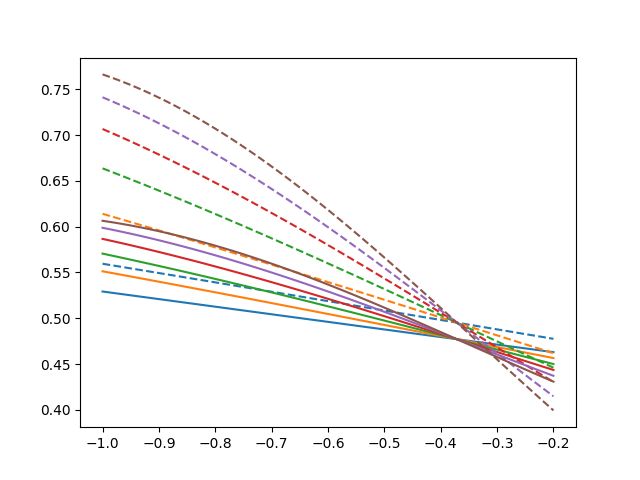

In [60]:
fig, ax = plt.subplots()

for i in range(6):
    ax.plot(drape_sweep_beta, drape_simulation[i][:, 2], linestyle='--', color=colors[i])
    ax.plot(drape_sweep_beta, drape_extended_simulation[i][:, 2], color=colors[i])

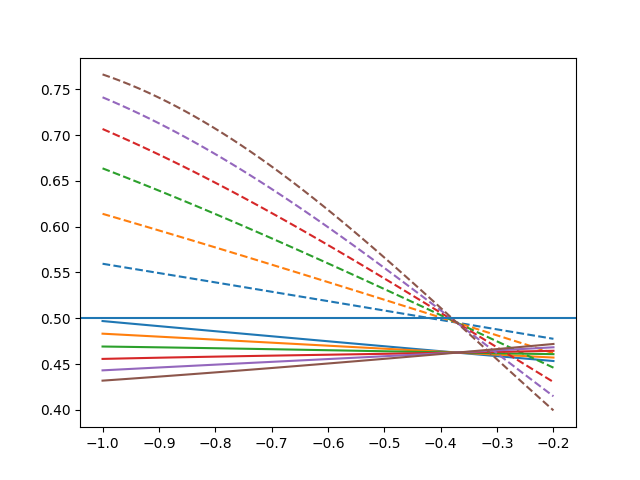

In [63]:
fig, ax = plt.subplots()

for i in range(6):
    ax.plot(drape_sweep_beta, drape_simulation[i][:, 2], linestyle='--', color=colors[i])
    ax.plot(drape_sweep_beta, drape_extended_simulation[i][:, 2], color=colors[i])

ax.axhline(0.5)